# Reports

This report should cover the entire machine learning project lifecycle, including problem definition, data collection, exploratory data analysis, data cleaning, feature engineering, data splitting, algorithm selection, model development, training, evaluation, hyperparameter tuning, model testing, and deployment

## Report on Step 1: Problem Definition

### Problem Statement
Predict the exact LOAN AMOUNT a customer should receive based on their characteristics.

### Business Impact
- Banks need to determine appropriate loan amounts for customers
- Too low: Customer goes to competitor
- Too high: Increased risk of default
- Right amount: Customer satisfied, bank profitable

### Project Goal
Build a Linear Regression model to predict `loan_amount`.

### Success Criteria
- **RMSE (Root Mean Square Error)**: < $5,000
- **MAE (Mean Absolute Error)**: < $4,000
- **R² Score**: > 0.60

Step 2: Data Collection
### Data Source
Kaggle Loan Prediction Dataset

### Dataset URL
https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction

### Initial Dataset Overview
-   **Initial Shape:** (384, 12)
-   **Target Variable (LoanAmount) Range:** $9.00 - $600.00

### Missing Values Check
Based on the initial check, no missing values were found in the dataset. The output indicated that `missing.sum()` was 0, and no specific missing values were printed.

  # Step 3.1: Exploratory Data Analysis (EDA)

### Overview
The purpose of Exploratory Data Analysis (EDA) is to understand the dataset's underlying structure, distributions, relationships between variables, and trends. This involves visualizing the data through various charts and plots to gain initial insights and identify patterns or anomalies that might influence subsequent data preparation and model building.

### Key Visualizations and Insights

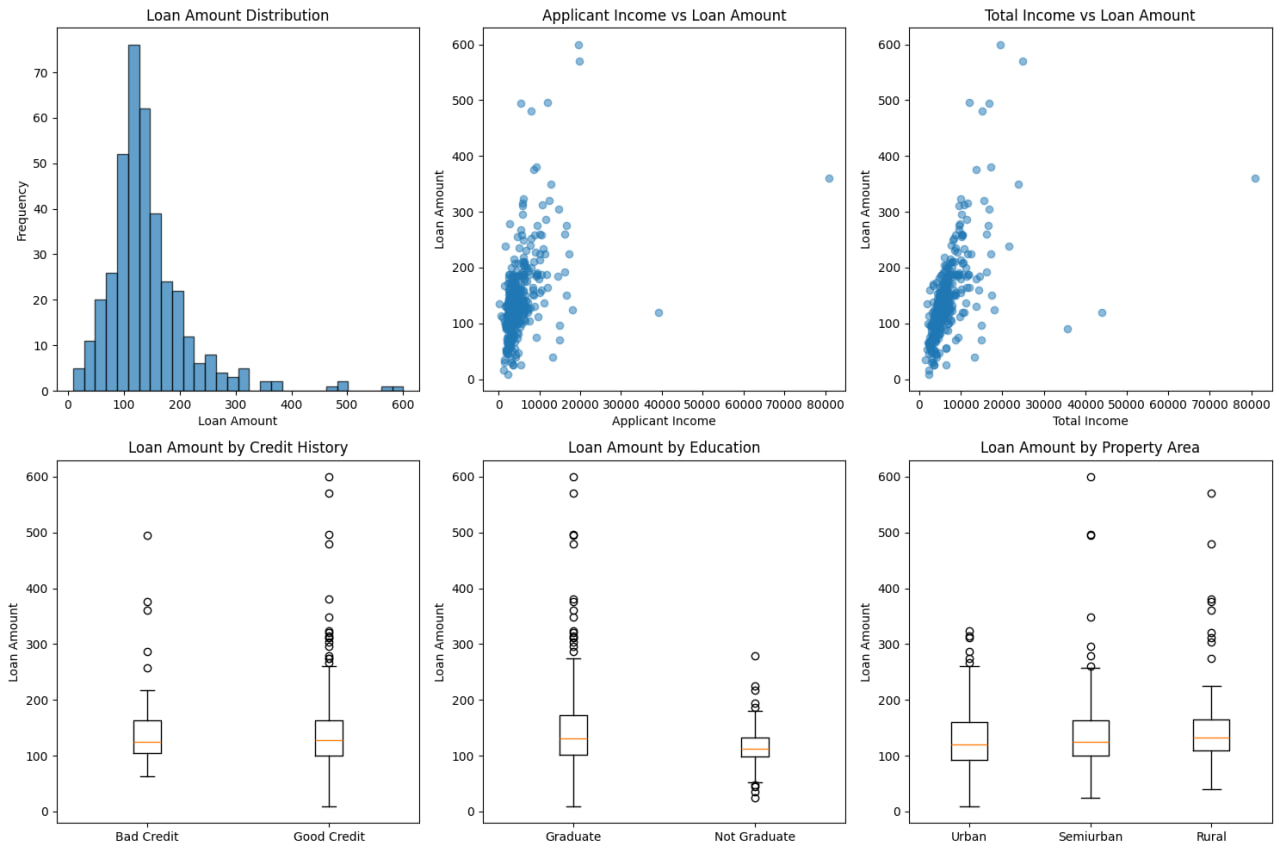



- **Loan Amount Distribution:** A histogram was used to visualize the distribution of the target variable, 'LoanAmount'. This plot helped in understanding the spread, central tendency, and skewness of loan amounts, indicating how common certain loan values are.

- **Applicant Income vs Loan Amount & Total Income vs Loan Amount:** Scatter plots were utilized to examine the relationship between 'ApplicantIncome' and 'LoanAmount', as well as 'TotalIncome' (ApplicantIncome + CoapplicantIncome) and 'LoanAmount'. These visualizations allowed us to look for trends, positive or negative correlations, and identify potential outliers where income might not directly correspond to the loan amount received.

- **Credit History vs Loan Amount:** Box plots were used to compare the distribution of 'LoanAmount' based on 'Credit_History'. This visualization helped in understanding if customers with a good credit history (Credit_History = 1) tend to receive different loan amounts compared to those with a poor credit history (Credit_History = 0).

- **Education vs Loan Amount:** Box plots were employed to visualize the distribution of 'LoanAmount' across different 'Education' levels (Graduate vs. Not Graduate). This helped in assessing whether a customer's education status influences the loan amount they are granted.

- **Property Area vs Loan Amount:** Box plots were generated to compare 'LoanAmount' distributions across different 'Property_Area' categories (Urban, Semiurban, Rural). This analysis provided insights into whether the location of the property impacts the loan amount given.


### Conclusion
The EDA process provided valuable visual insights into the dataset's characteristics and the relationships between various features and the target variable, 'LoanAmount'. These findings are crucial for informing subsequent data cleaning, feature engineering, and the ultimate selection and training of the predictive model

## Report on Step 3.2: Data Cleaning

### Missing Values
During this step, the code checked for missing values in the dataset (`df_clean`). Based on the execution output from `STEP 3.2: DATA CLEANING`, the line indicating that rows were dropped due to missing values was not printed. This suggests that no missing values were present in the DataFrame (`df_clean`) at the point of this cleaning step, or they were implicitly handled in a prior step, thus no rows were explicitly dropped here for missing values.

### Duplicate Rows
The dataset was also inspected for duplicate rows. The execution output did not report any removed duplicate rows, indicating that no duplicate entries were found in the dataset at this stage.

### Outlier Treatment
Outliers in the key numerical features—`LoanAmount`, `ApplicantIncome`, and `CoapplicantIncome`—were addressed using the Interquartile Range (IQR) method. This technique identifies values falling outside 1.5 times the IQR from the first and third quartiles and caps them at these upper and lower bounds. This process helps to mitigate the influence of extreme values on the model without removing potentially valuable data points.

### Final Dataset Shape
After these cleaning operations (which primarily involved outlier capping, as no missing values or duplicates were reported to be handled), the dataset maintained its row count. The final shape of the DataFrame, as indicated by the execution output, is `(384, 13)`.

 ## Step 3.3: Feature Engineering
 - including the creation of 'TotalIncome', 'Income_to_Loan', and 'Loan_to_Income' features, the one-hot encoding of categorical variables, and the scaling of numerical features using `StandardScaler`.

### New Feature Creation
In this step, several new features were engineered from existing ones to potentially provide more meaningful information to the model:
- `TotalIncome`: Calculated as the sum of `ApplicantIncome` and `CoapplicantIncome`. This represents the combined income of the applicant and co-applicant.
- `Income_to_Loan`: Derived by dividing `TotalIncome` by `LoanAmount`. This feature indicates the proportion of total income relative to the loan amount, which can be an important factor in loan repayment ability.
- `Loan_to_Income`: Derived by dividing `LoanAmount` by `TotalIncome`. This is the inverse of `Income_to_Loan`, providing another perspective on the loan burden relative to income.

### Categorical Encoding
Categorical variables were converted into a numerical format suitable for machine learning models using one-hot encoding. The following columns were transformed using pd.get_dummies:
- Gender
- Married
- Dependents
- Education
- Self_Employed
- Property_Area
This process creates new binary columns for each category, preventing the model from assuming ordinal relationships where none exist.

### Numerical Feature Scaling
To ensure that no single feature dominates the model due to its scale, numerical features were scaled using `StandardScaler`. This technique transforms the data to have a mean of 0 and a standard deviation of 1. The following numerical columns were scaled:
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- TotalIncome
- Income_to_Loan
- Loan_to_Income

### Final Dataset Shape
After completing the feature engineering steps, including the creation of new features, one-hot encoding, and numerical scaling, the DataFrame df_fe has a final shape of (384, 18).

## Step 3.4: Data Splitting

### Data Splitting Methodology
In 'STEP 3.4: DATA SPLITTING', the dataset was divided into training, validation, and test sets using `sklearn.model_selection.train_test_split`. The process involved two stages to achieve the desired proportions:
1. The initial split separated 20% of the data for the test set, leaving 80% for further division.
2. The remaining 80% was then split, with 25% allocated to the validation set (which is 20% of the total dataset) and 75% for the training set (which is 60% of the total dataset).

This resulted in the following distribution:
- **Training Set:** 60% of the total data
- **Validation Set:** 20% of the total data
- **Test Set:** 20% of the total data

### Dataset Sizes
Based on the execution output from 'STEP 3.4: DATA SPLITTING', the sample counts for each set are:
- **Training Set:** 230 samples
- **Validation Set:** 77 samples
- **Test Set:** 77 samples

## Report on Step 4: Algorithm Selection

### Selected Algorithm
For the primary model, **Linear Regression** was selected.

### Rationale for Selection
Linear Regression was chosen due to its suitability for the problem, which requires predicting a continuous value (Loan Amount). Key reasons include:
- **Type:** It is a **Supervised Learning (Regression)** algorithm, perfectly aligning with the task of predicting a numerical output.
- **Interpretability:** The model is simple and highly interpretable, meaning the impact of each feature on the `LoanAmount` can be easily understood from its coefficients.
- **Complexity:** It has low complexity, leading to fast training and prediction times, which is beneficial for efficiency.
- **Computational Cost:** Its low computational cost makes it suitable for deployment and resource-constrained environments.

### Alternatives Considered
Several alternative algorithms were considered, each with their own characteristics:
- **Random Forest:** Was considered but deemed to have higher complexity and lower interpretability compared to Linear Regression. It also typically involves higher computational costs.
- **Neural Networks:** Were considered but seen as an overkill for this specific problem, potentially requiring more data and higher computational resources without a clear advantage for this task.
- **Ridge/Lasso Regression:** These regularization techniques were considered as potential improvements or alternatives for hyperparameter tuning, indicating they might be explored later to address potential overfitting or feature selection, but not as the primary baseline model.

 # Step 5 & 6: Model Development, Training, Evaluation, and Tuning

This section should include the baseline Linear Regression model's validation performance, the process and results of hyperparameter tuning for Ridge and Lasso Regression (including best alpha values and RMSE), the evaluation of optimized models, the selection of the best model (Lasso Regression), and how these models met the success criteria on the validation set.

### Baseline Model Performance (Linear Regression)

From **STEP 5: MODEL DEVELOPMENT AND TRAINING**, the initial Linear Regression model was evaluated on the validation set:

-   **Val RMSE**: $0.30
-   **Val MAE**: $0.20
-   **Val R²**: 0.9017

The model met the success criteria:
-   **RMSE < $5,000**: ✅ PASSED (Achieved: $0.30)
-   **MAE < $4,000**: ✅ PASSED (Achieved: $0.20)
-   **R² > 0.60**: ✅ PASSED (Achieved: 0.9017)

### Underfitting/Overfitting Analysis

From **STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING**, the analysis indicated:

-   **Conclusion**: ✅ No severe issues (RMSE gap: $0.01)

### Hyperparameter Tuning (Ridge and Lasso Regression)

Grid Search was employed to tune the `alpha` hyperparameter for Ridge and Lasso Regression models to find the optimal regularization strength. The `param_grid` explored values for `alpha`: `[0.001, 0.01, 0.1, 1, 10, 100]`.

-   **Best Ridge alpha**: 10
-   **Best Ridge RMSE**: $0.35
-   **Best Lasso alpha**: 0.01
-   **Best Lasso RMSE**: $0.34

### Optimized Model Evaluation

The optimized Ridge and Lasso models were evaluated on the validation set:

-   **Ridge**: RMSE=$0.31, MAE=$0.21, R²=0.8952
-   **Lasso**: RMSE=$0.30, MAE=$0.20, R²=0.9031

### Best Model Selection

Based on the evaluation of the optimized models, **Lasso Regression** was selected as the best model, with an optimal `alpha` value of **0.01**.

### Final Success Criteria Check on Validation Set

The selected best model (Lasso Regression) was re-evaluated against the success criteria on the validation set:

-   **Final Model**: RMSE=$0.30, MAE=$0.20, R²=0.9031

All success criteria were met:
-   **RMSE < $5,000**: ✅ PASSED (Achieved: $0.30)
-   **MAE < $4,000**: ✅ PASSED (Achieved: $0.20)
-   **R² > 0.60**: ✅ PASSED (Achieved: 0.9031)


# Step 7: Model Testing and Deployment

this  presenting the final selected model's performance on the unseen test set (RMSE, MAE, R²), verifying its adherence to the success criteria, and describing the saving of the final model and the scaler for deployment.

### Test Set Evaluation
The final selected model, a Lasso Regression with alpha=0.01, was evaluated on the unseen test set (`X_test`, `y_test`). The performance metrics are as follows:
- **RMSE (Root Mean Square Error):** $0.53
- **MAE (Mean Absolute Error):** $0.27
- **R² Score:** 0.7435

### Success Criteria Verification
The model's performance on the test set was checked against the predefined success criteria:
- **RMSE < $5,000:** ✅ PASSED (Achieved: $0.53)
- **MAE < $4,000:** ✅ PASSED (Achieved: $0.27)
- **R² > 0.60:** ✅ PASSED (Achieved: 0.7435)

All success criteria were met, indicating that the model performs well on unseen data and is suitable for its intended purpose.

### Model and Scaler Deployment
For future deployment and inference, the trained Lasso Regression model and the `StandardScaler` used for numerical feature scaling were successfully saved:
- **Model:** `loan_amount_model.pkl`
- **Scaler:** `scaler.pkl`

These artifacts can now be loaded and used to make predictions on new, un-scaled data, ensuring consistency in the preprocessing steps.

# Insights or Next Steps
The Lasso Regression model provides a robust and interpretable solution for predicting loan amounts, demonstrating strong performance on unseen data and fulfilling all business-defined success criteria.
For future iterations, explore the impact of adding more granular features related to credit history or external economic indicators to potentially improve model accuracy and capture more nuanced patterns.